# Experiment 6.0 — Multi-timescale phase-aware evidence + synapse-update ablation

Analysis-only notebook. All 54 SNN trainings, checkpoint selection, test evaluation, activity extraction, and aggregation are completed by the Exp6.0 CPU pipeline before this notebook is opened.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO_ROOT = Path('..').resolve()
ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_6_0_multiscale_phase_evidence' / 'single_hidden_multiscale_phase_evidence_v1'
runs = pd.read_csv(ROOT / 'runs.csv')
summary = pd.read_csv(ROOT / 'summary.csv')
paired = pd.read_csv(ROOT / 'paired_synapse_update_deltas.csv')
history_index = pd.read_csv(ROOT / 'history_index.csv')
baseline = json.loads((ROOT / 'baseline_fixed250_linear.json').read_text())
manifest = json.loads((ROOT / 'manifest.json').read_text())
sample = json.loads((ROOT / 'visualization_sample.json').read_text())
print('runs:', len(runs))
print('synapse modes:', runs.synapse_mode.value_counts().to_dict())
print('visualization sample:', sample)


runs: 54
synapse modes: {'normalized_unit_dc': 27, 'legacy_unnormalized': 27}
visualization sample: {'label': 'X', 'label_index': 11, 'selection_rule': 'same deterministic validation sample for all 54 paired runs; selected before inspecting model results', 'valid_length': 90, 'validation_index': 39, 'visualization_steps': 256}


## Run-level results and Fixed250 reference

In [2]:
display(runs.sort_values(['synapse_mode', 'objective', 'mem_shift', 'seed']))
display(summary)
baseline_metrics = baseline['baseline']['metrics']
display(pd.DataFrame(baseline_metrics).T)


,objective,mem_shift,tau_mem_ms,seed,best_epoch,train_loss,val_loss,train_ba,val_ba,test_ba,...,hidden_s4_fr_tail,hidden_s4_fr_valid,hidden_s5_fr_tail,hidden_s5_fr_valid,hidden_s6_fr_tail,hidden_s6_fr_valid,output_fr_tail,output_fr_valid,synapse_mode,synaptic_update
27,whole_count,1,22.542110,11,97,1.228836,1.640002,0.776857,0.466973,0.409769,...,0.001401,0.028165,0.015130,0.077519,0.064974,0.162169,0.058233,0.284259,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t
28,whole_count,1,22.542110,23,51,1.529562,1.756371,0.608763,0.463438,0.402665,...,0.000140,0.008010,0.002101,0.025065,0.048766,0.132804,0.058735,0.194444,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t
29,whole_count,1,22.542110,37,94,1.299343,1.643038,0.732347,0.466342,0.442167,...,0.000420,0.011628,0.002802,0.049354,0.065404,0.142063,0.099900,0.227778,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t
30,whole_count,2,54.313430,11,85,1.343851,1.665246,0.706576,0.456355,0.385161,...,0.003923,0.040052,0.020314,0.105426,0.096386,0.202910,0.072289,0.265741,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t
31,whole_count,2,54.313430,23,89,1.359735,1.663452,0.716073,0.491913,0.422190,...,0.002101,0.043152,0.010087,0.073643,0.094234,0.199471,0.085843,0.245370,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t
32,whole_count,2,54.313430,37,59,1.530945,1.726615,0.602755,0.449874,0.383490,...,0.001261,0.029716,0.009386,0.082171,0.075158,0.169312,0.081325,0.242593,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t
33,whole_count,3,117.013683,11,84,1.408134,1.685342,0.652658,0.459632,0.365733,...,0.006725,0.056589,0.023116,0.105426,0.121916,0.221164,0.087349,0.258333,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t
34,whole_count,3,117.013683,23,81,1.441086,1.699103,0.650211,0.483448,0.399900,...,0.004203,0.063307,0.014990,0.090181,0.118044,0.227513,0.072791,0.221296,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t
35,whole_count,3,117.013683,37,92,1.421985,1.694288,0.694226,0.452489,0.376830,...,0.004623,0.051680,0.017652,0.103359,0.104705,0.199206,0.110442,0.252778,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t
45,whole_count_contextual_gain,1,22.542110,11,87,1.604564,1.762545,0.567868,0.432822,0.347077,...,0.005324,0.138243,0.004203,0.055297,0.047189,0.155291,0.045181,0.236111,legacy_unnormalized,I_t = alpha*I_{t-1} + W*x_t


,synapse_mode,objective,mem_shift,tau_mem_ms,val_ba_mean,val_ba_std,test_ba_mean,test_ba_std,test_accuracy_mean,test_accuracy_std,...,hidden_s5_fr_valid_mean,hidden_s5_fr_valid_std,hidden_s6_fr_valid_mean,hidden_s6_fr_valid_std,hidden_s4_fr_tail_mean,hidden_s4_fr_tail_std,hidden_s5_fr_tail_mean,hidden_s5_fr_tail_std,hidden_s6_fr_tail_mean,hidden_s6_fr_tail_std
0,legacy_unnormalized,whole_count,1,22.542110,0.465584,0.001886,0.418200,0.021058,0.429224,0.019772,...,0.050646,0.026251,0.145679,0.015013,0.000654,0.000662,0.006678,0.007328,0.059715,0.009484
1,legacy_unnormalized,whole_count,2,54.313430,0.466047,0.022634,0.396947,0.021877,0.410959,0.023727,...,0.087080,0.016450,0.190564,0.018485,0.002428,0.001361,0.013262,0.006117,0.088592,0.011684
2,legacy_unnormalized,whole_count,3,117.013683,0.465190,0.016210,0.380821,0.017430,0.394977,0.020925,...,0.099655,0.008270,0.215961,0.014853,0.005184,0.001351,0.018586,0.004142,0.114888,0.009029
3,legacy_unnormalized,whole_count_contextual_gain,1,22.542110,0.430459,0.011064,0.358494,0.025682,0.369863,0.018122,...,0.060810,0.008033,0.153704,0.008838,0.004576,0.000772,0.004063,0.000642,0.046711,0.009619
4,legacy_unnormalized,whole_count_contextual_gain,2,54.313430,0.411913,0.012967,0.362792,0.014613,0.374429,0.020925,...,0.088286,0.001720,0.172134,0.013228,0.011348,0.000852,0.009667,0.001147,0.063540,0.008875
5,legacy_unnormalized,whole_count_contextual_gain,3,117.013683,0.405578,0.007956,0.327636,0.005544,0.342466,0.006849,...,0.102584,0.010490,0.178307,0.009505,0.014710,0.000505,0.015551,0.001986,0.075301,0.006461
6,legacy_unnormalized,whole_count_hce,1,22.542110,0.389779,0.038776,0.331206,0.009177,0.344749,0.010463,...,0.049957,0.010860,0.172134,0.016543,0.001401,0.000875,0.009993,0.001403,0.090218,0.003759
7,legacy_unnormalized,whole_count_hce,2,54.313430,0.337877,0.011940,0.286080,0.009681,0.305936,0.003954,...,0.112489,0.018515,0.253175,0.037302,0.006258,0.003202,0.025404,0.007432,0.142522,0.027429
8,legacy_unnormalized,whole_count_hce,3,117.013683,0.337203,0.029672,0.270171,0.014261,0.292237,0.017237,...,0.149182,0.050313,0.268871,0.020622,0.010694,0.001263,0.036985,0.011078,0.167718,0.027847
9,normalized_unit_dc,whole_count,1,22.542110,0.083333,0.000000,0.083333,0.000000,0.075342,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,accuracy,balanced_accuracy,macro_f1
test,0.554795,0.548475,0.537217
train,0.998279,0.998366,0.998381
val,0.595238,0.587290,0.599695


## Test Balanced Accuracy vs hidden membrane shift

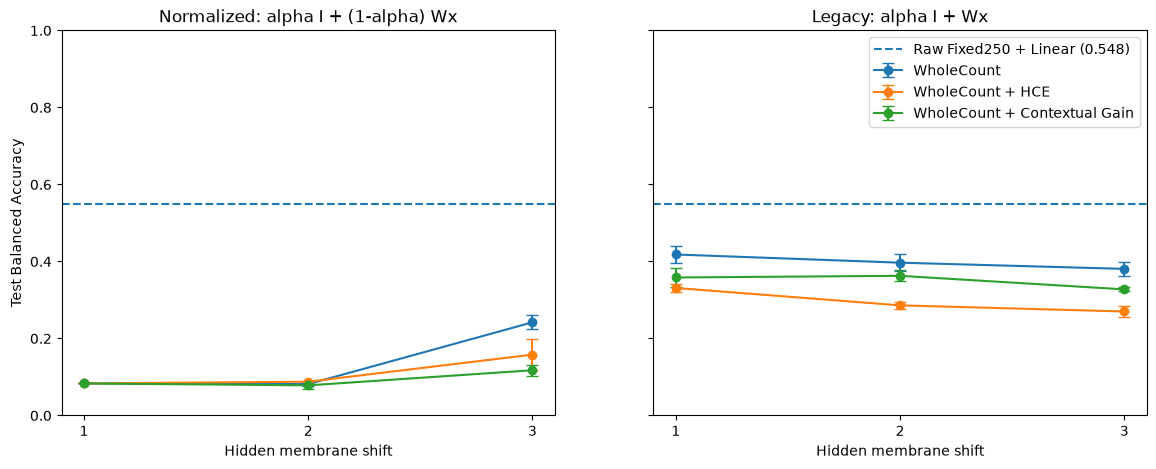

In [3]:
objective_labels = {
    'whole_count': 'WholeCount',
    'whole_count_hce': 'WholeCount + HCE',
    'whole_count_contextual_gain': 'WholeCount + Contextual Gain',
}
mode_labels = {
    'normalized_unit_dc': 'Normalized: alpha I + (1-alpha) Wx',
    'legacy_unnormalized': 'Legacy: alpha I + Wx',
}
reference = float(baseline_metrics['test']['balanced_accuracy'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (mode, mode_label) in zip(axes, mode_labels.items()):
    mode_rows = runs[runs.synapse_mode == mode]
    for objective, label in objective_labels.items():
        subset = mode_rows[mode_rows.objective == objective]
        stats = subset.groupby('mem_shift').test_ba.agg(['mean', 'std']).reindex([1, 2, 3])
        ax.errorbar(stats.index, stats['mean'], yerr=stats['std'].fillna(0), marker='o', capsize=4, label=label)
    ax.axhline(reference, linestyle='--', label=f'Raw Fixed250 + Linear ({reference:.3f})')
    ax.set_title(mode_label)
    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('Hidden membrane shift')
    ax.set_ylim(0, 1)
axes[0].set_ylabel('Test Balanced Accuracy')
axes[-1].legend()
plt.show()


## Paired synapse-update effect

,objective,mem_shift,seed,val_ba_normalized,test_ba_normalized,test_accuracy_normalized,test_macro_f1_normalized,hidden_s4_fr_valid_normalized,hidden_s5_fr_valid_normalized,hidden_s6_fr_valid_normalized,...,val_ba_legacy_minus_normalized,test_ba_legacy_minus_normalized,test_accuracy_legacy_minus_normalized,test_macro_f1_legacy_minus_normalized,hidden_s4_fr_valid_legacy_minus_normalized,hidden_s5_fr_valid_legacy_minus_normalized,hidden_s6_fr_valid_legacy_minus_normalized,hidden_s4_fr_tail_legacy_minus_normalized,hidden_s5_fr_tail_legacy_minus_normalized,hidden_s6_fr_tail_legacy_minus_normalized
0,whole_count,1,11,0.083333,0.083333,0.075342,0.011677,0.000000,0.000000,0.000000,...,0.383640,0.326435,0.342466,0.388992,0.028165,0.077519,0.162169,0.001401,0.015130,0.064974
1,whole_count,1,23,0.083333,0.083333,0.075342,0.011677,0.000000,0.000000,0.000000,...,0.380105,0.319331,0.342466,0.362704,0.008010,0.025065,0.132804,0.000140,0.002101,0.048766
2,whole_count,1,37,0.083333,0.083333,0.075342,0.011677,0.000000,0.000000,0.000000,...,0.383009,0.358834,0.376712,0.408708,0.011628,0.049354,0.142063,0.000420,0.002802,0.065404
3,whole_count,2,11,0.119048,0.082251,0.089041,0.023910,0.000000,0.000000,0.000000,...,0.337308,0.302910,0.308219,0.349841,0.040052,0.105426,0.202910,0.003923,0.020314,0.096386
4,whole_count,2,23,0.118056,0.086039,0.082192,0.022365,0.001034,0.000000,0.000000,...,0.373858,0.336151,0.356164,0.377881,0.042119,0.073643,0.199471,0.002101,0.010087,0.094234
5,whole_count,2,37,0.125000,0.076299,0.082192,0.026641,0.000775,0.000000,0.000000,...,0.324874,0.307191,0.315068,0.345882,0.028941,0.082171,0.169312,0.001261,0.009386,0.075158
6,whole_count,3,11,0.329365,0.246180,0.267123,0.169515,0.006202,0.004651,0.000265,...,0.130267,0.119553,0.109589,0.173931,0.050388,0.100775,0.220899,0.006725,0.023116,0.121916
7,whole_count,3,23,0.244180,0.258086,0.273973,0.184381,0.006202,0.003101,0.000265,...,0.239268,0.141814,0.143836,0.199039,0.057106,0.087080,0.227249,0.004063,0.014710,0.118044
8,whole_count,3,37,0.241402,0.221653,0.246575,0.125763,0.006202,0.002067,0.000794,...,0.211087,0.155177,0.143836,0.241669,0.045478,0.101292,0.198413,0.004483,0.017372,0.104561
18,whole_count_contextual_gain,1,11,0.083333,0.083333,0.075342,0.011677,0.000000,0.000000,0.000000,...,0.349489,0.263743,0.287671,0.308973,0.138243,0.055297,0.155291,0.005324,0.004203,0.047189


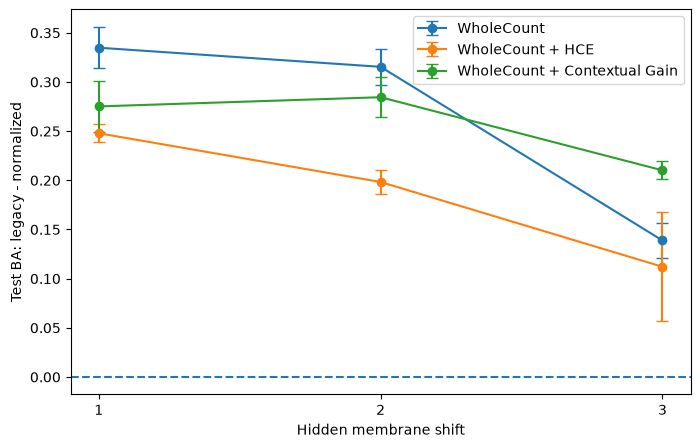

In [4]:
display(paired.sort_values(['objective', 'mem_shift', 'seed']))
delta_col = 'test_ba_legacy_minus_normalized'
fig, ax = plt.subplots(figsize=(8, 5))
for objective, label in objective_labels.items():
    subset = paired[paired.objective == objective]
    stats = subset.groupby('mem_shift')[delta_col].agg(['mean', 'std']).reindex([1, 2, 3])
    ax.errorbar(stats.index, stats['mean'], yerr=stats['std'].fillna(0), marker='o', capsize=4, label=label)
ax.axhline(0, linestyle='--')
ax.set_xticks([1, 2, 3])
ax.set_xlabel('Hidden membrane shift')
ax.set_ylabel('Test BA: legacy - normalized')
ax.legend()
plt.show()


## Validation BA and hidden firing diagnostics

In [5]:
fr_cols = ['hidden_s4_fr_valid', 'hidden_s5_fr_valid', 'hidden_s6_fr_valid', 'hidden_s4_fr_tail', 'hidden_s5_fr_tail', 'hidden_s6_fr_tail']
display(runs.groupby(['synapse_mode', 'objective', 'mem_shift'])[['val_ba', *fr_cols]].agg(['mean', 'std']))


val_ba            \
                                                               mean       std   
synapse_mode        objective                   mem_shift                       
legacy_unnormalized whole_count                 1          0.465584  0.001886   
                                                2          0.466047  0.022634   
                                                3          0.465190  0.016210   
                    whole_count_contextual_gain 1          0.430459  0.011064   
                                                2          0.411913  0.012967   
                                                3          0.405578  0.007956   
                    whole_count_hce             1          0.389779  0.038776   
                                                2          0.337877  0.011940   
                                                3          0.337203  0.029672   
normalized_unit_dc  whole_count                 1          0.083333  0.000000   
                                                2          0.120701  0.003756   
                                                3          0.271649  0.050003   
                    whole_count_contextual_gain 1          0.083333  0.000000   
                                                2          0.086111  0.004811   
                                                3          0.134620  0.009473   
                    whole_count_hce             1          0.083333  0.000000   
                                                2          0.090741  0.006991   
                                                3          0.166931  0.033357   

                                                          hidden_s4_fr_valid  \
                                                                        mean   
synapse_mode        objective                   mem_shift                      
legacy_unnormalized whole_count                 1                   0.015935   
                                                2                   0.037640   
                                                3                   0.057192   
                    whole_count_contextual_gain 1                   0.129544   
                                                2                   0.176830   
                                                3                   0.184927   
                    whole_count_hce             1                   0.020586   
                                                2                   0.067356   
                                                3                   0.099139   
normalized_unit_dc  whole_count                 1                   0.000000   
                                                2                   0.000603   
                                                3                   0.006202   
                    whole_count_contextual_gain 1                   0.000000   
                                                2                   0.000000   
                                                3                   0.020758   
                    whole_count_hce             1                   0.000000   
                                                2                   0.000000   
                                                3                   0.000947   

                                                                     \
                                                                std   
synapse_mode        objective                   mem_shift             
legacy_unnormalized whole_count                 1          0.010746   
                                                2          0.007036   
                                                3          0.005837   
                    whole_count_contextual_gain 1          0.015068   
                                                2          0.009307   
                                                3          0.007813   
                    whole_count_hce    

## Matched learning curves and spike rasters

All runs use the same deterministic validation segment. The following cell shows one matched normalized/legacy pair.

legacy_unnormalized


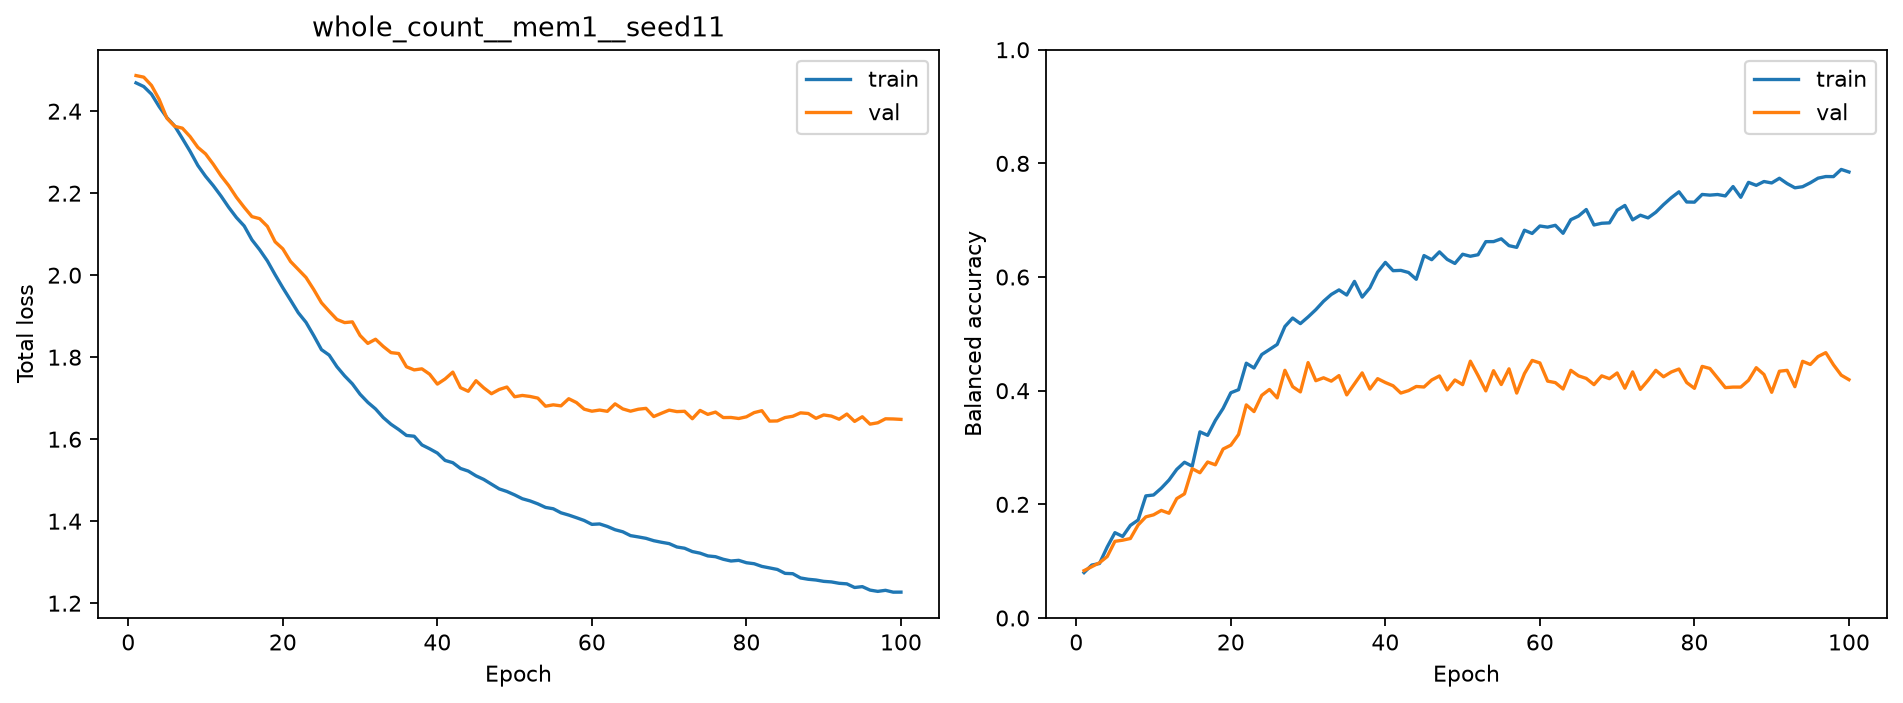

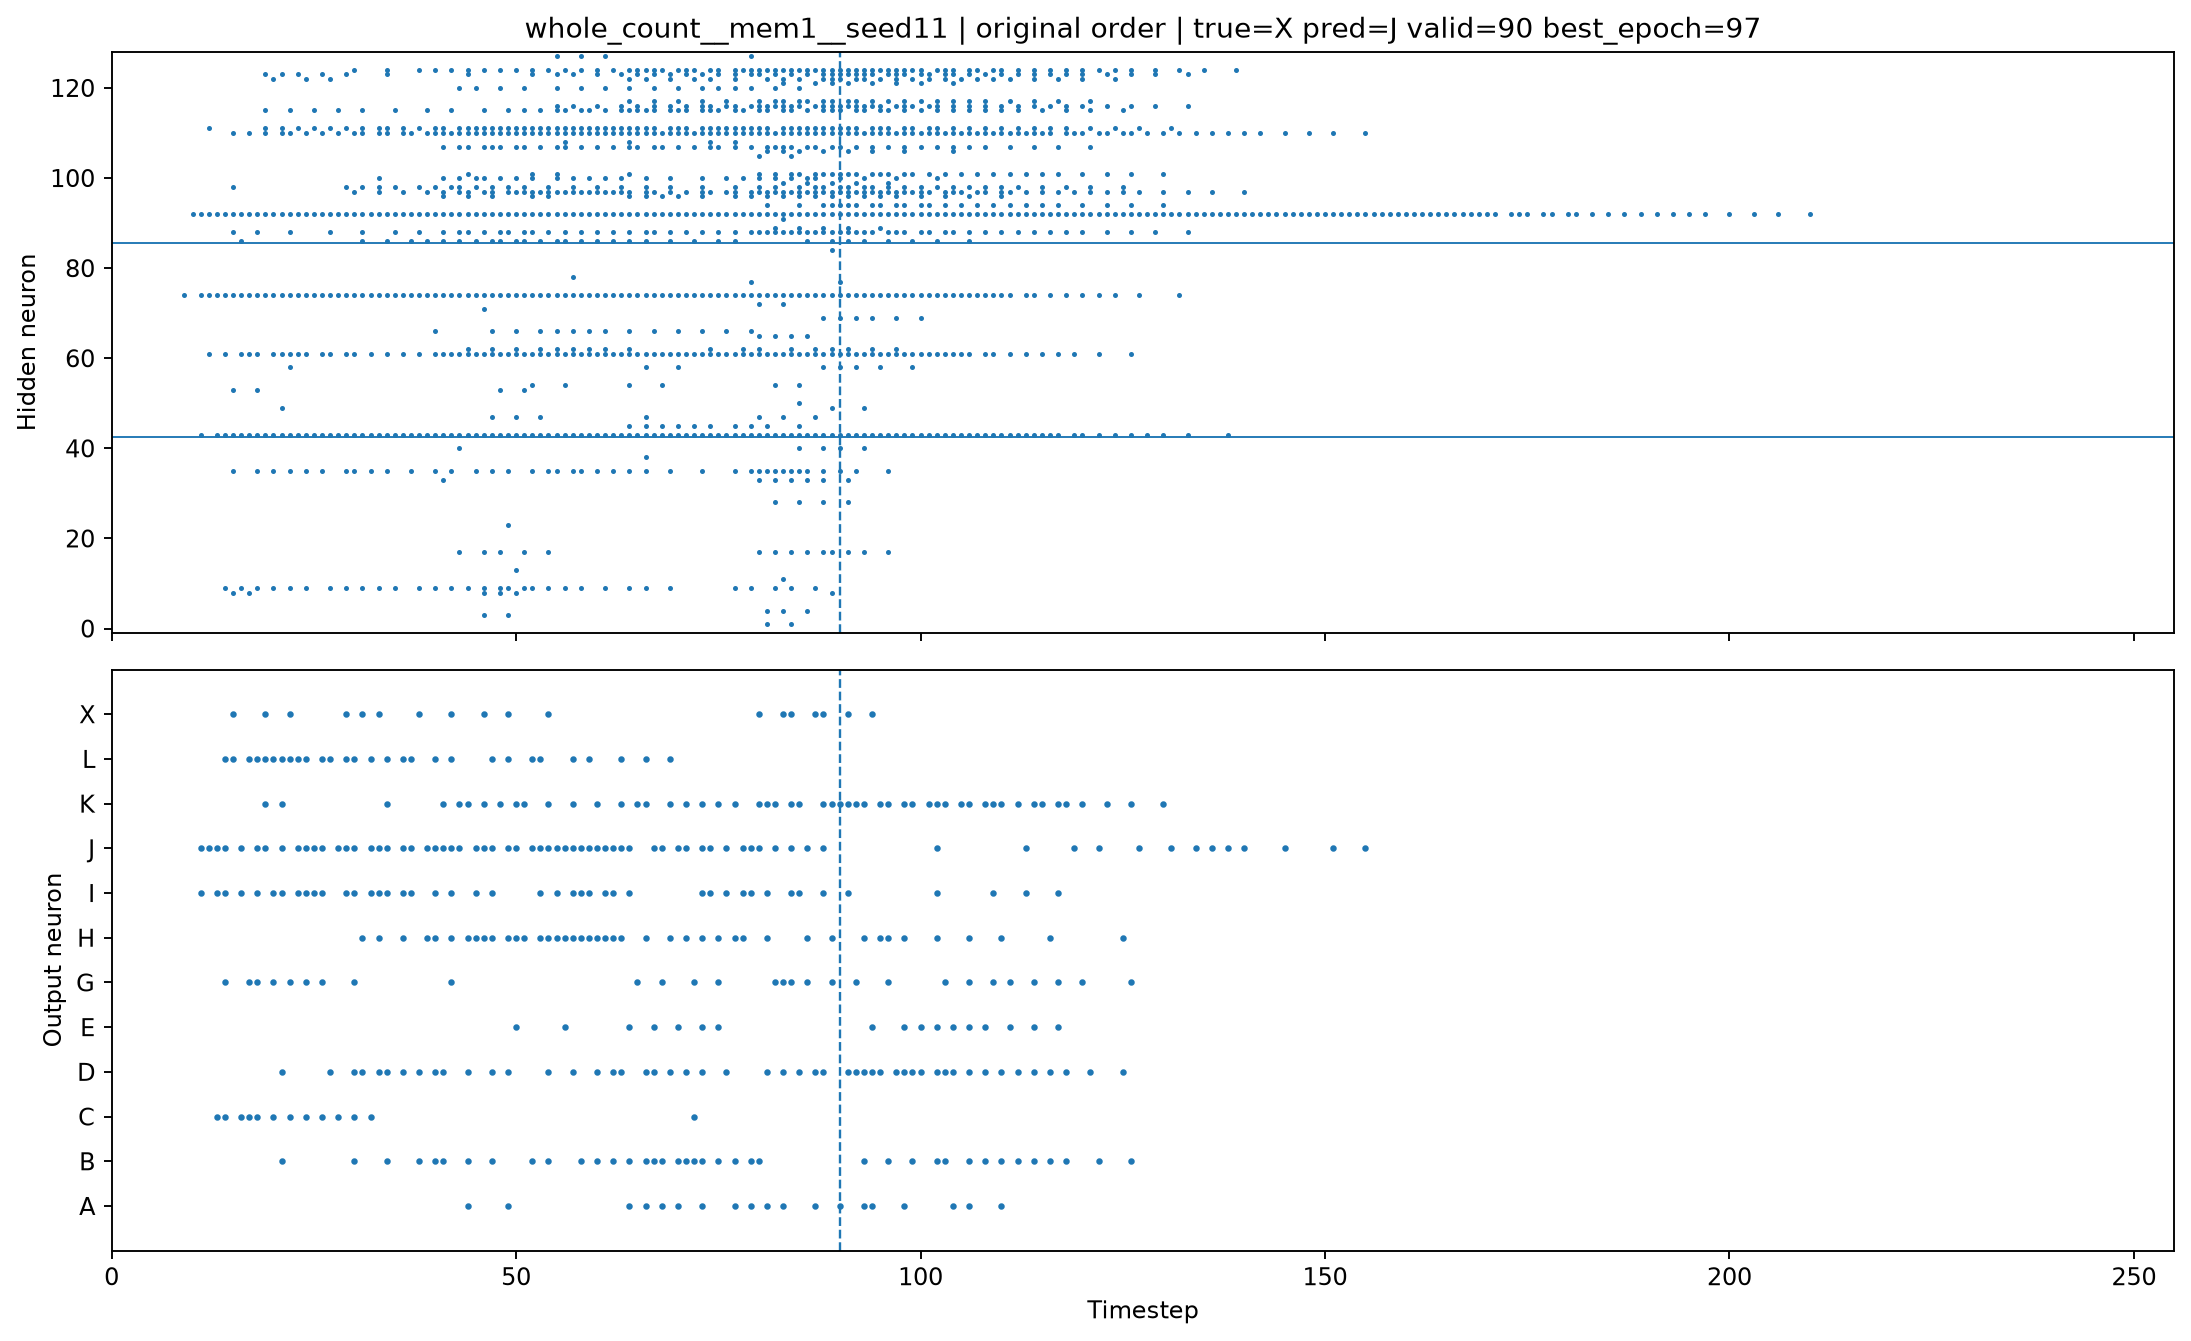

normalized_unit_dc


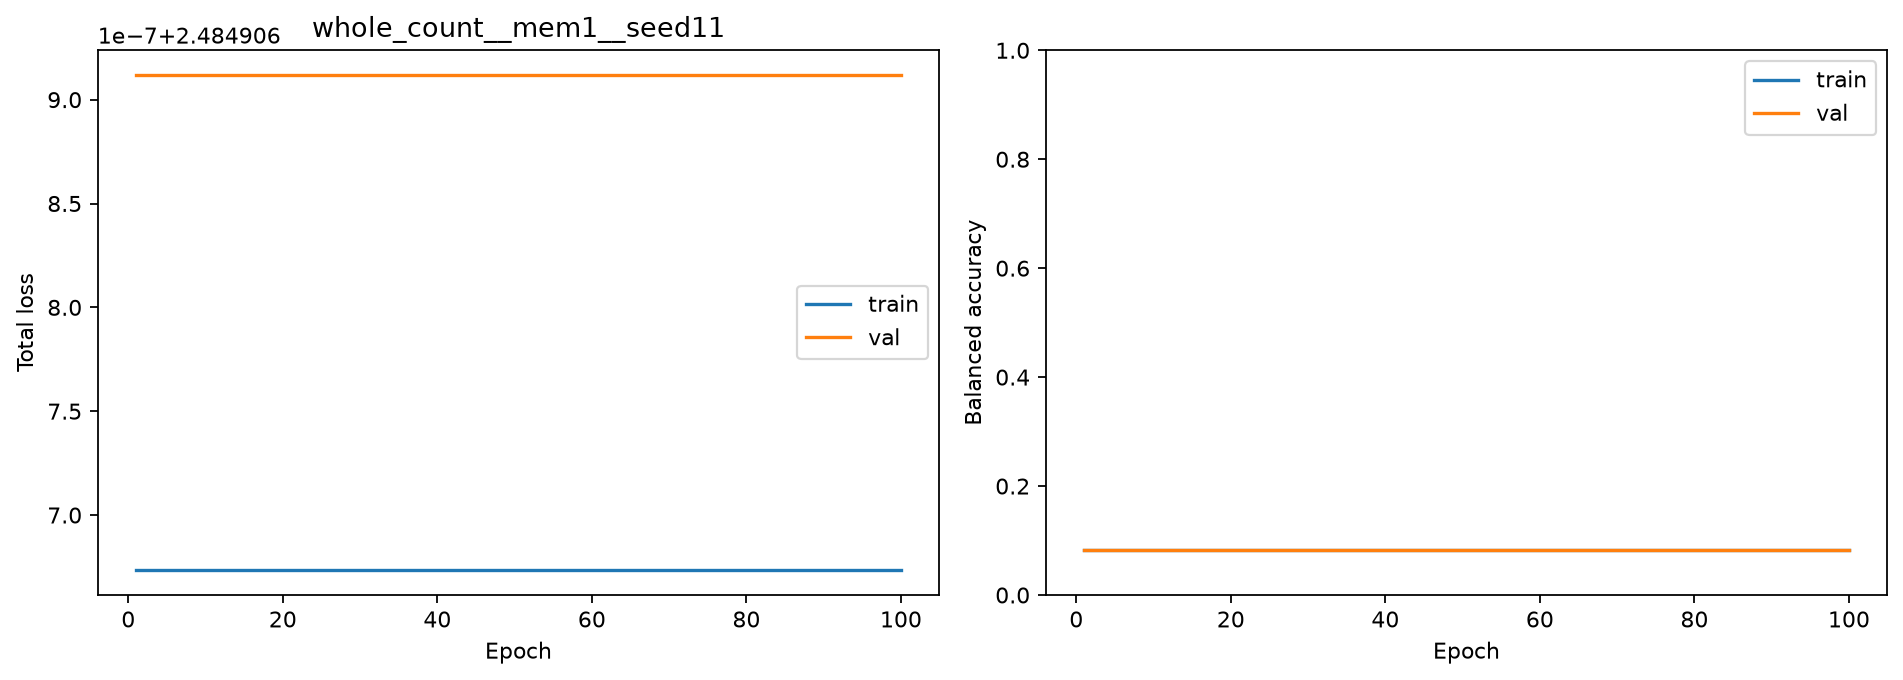

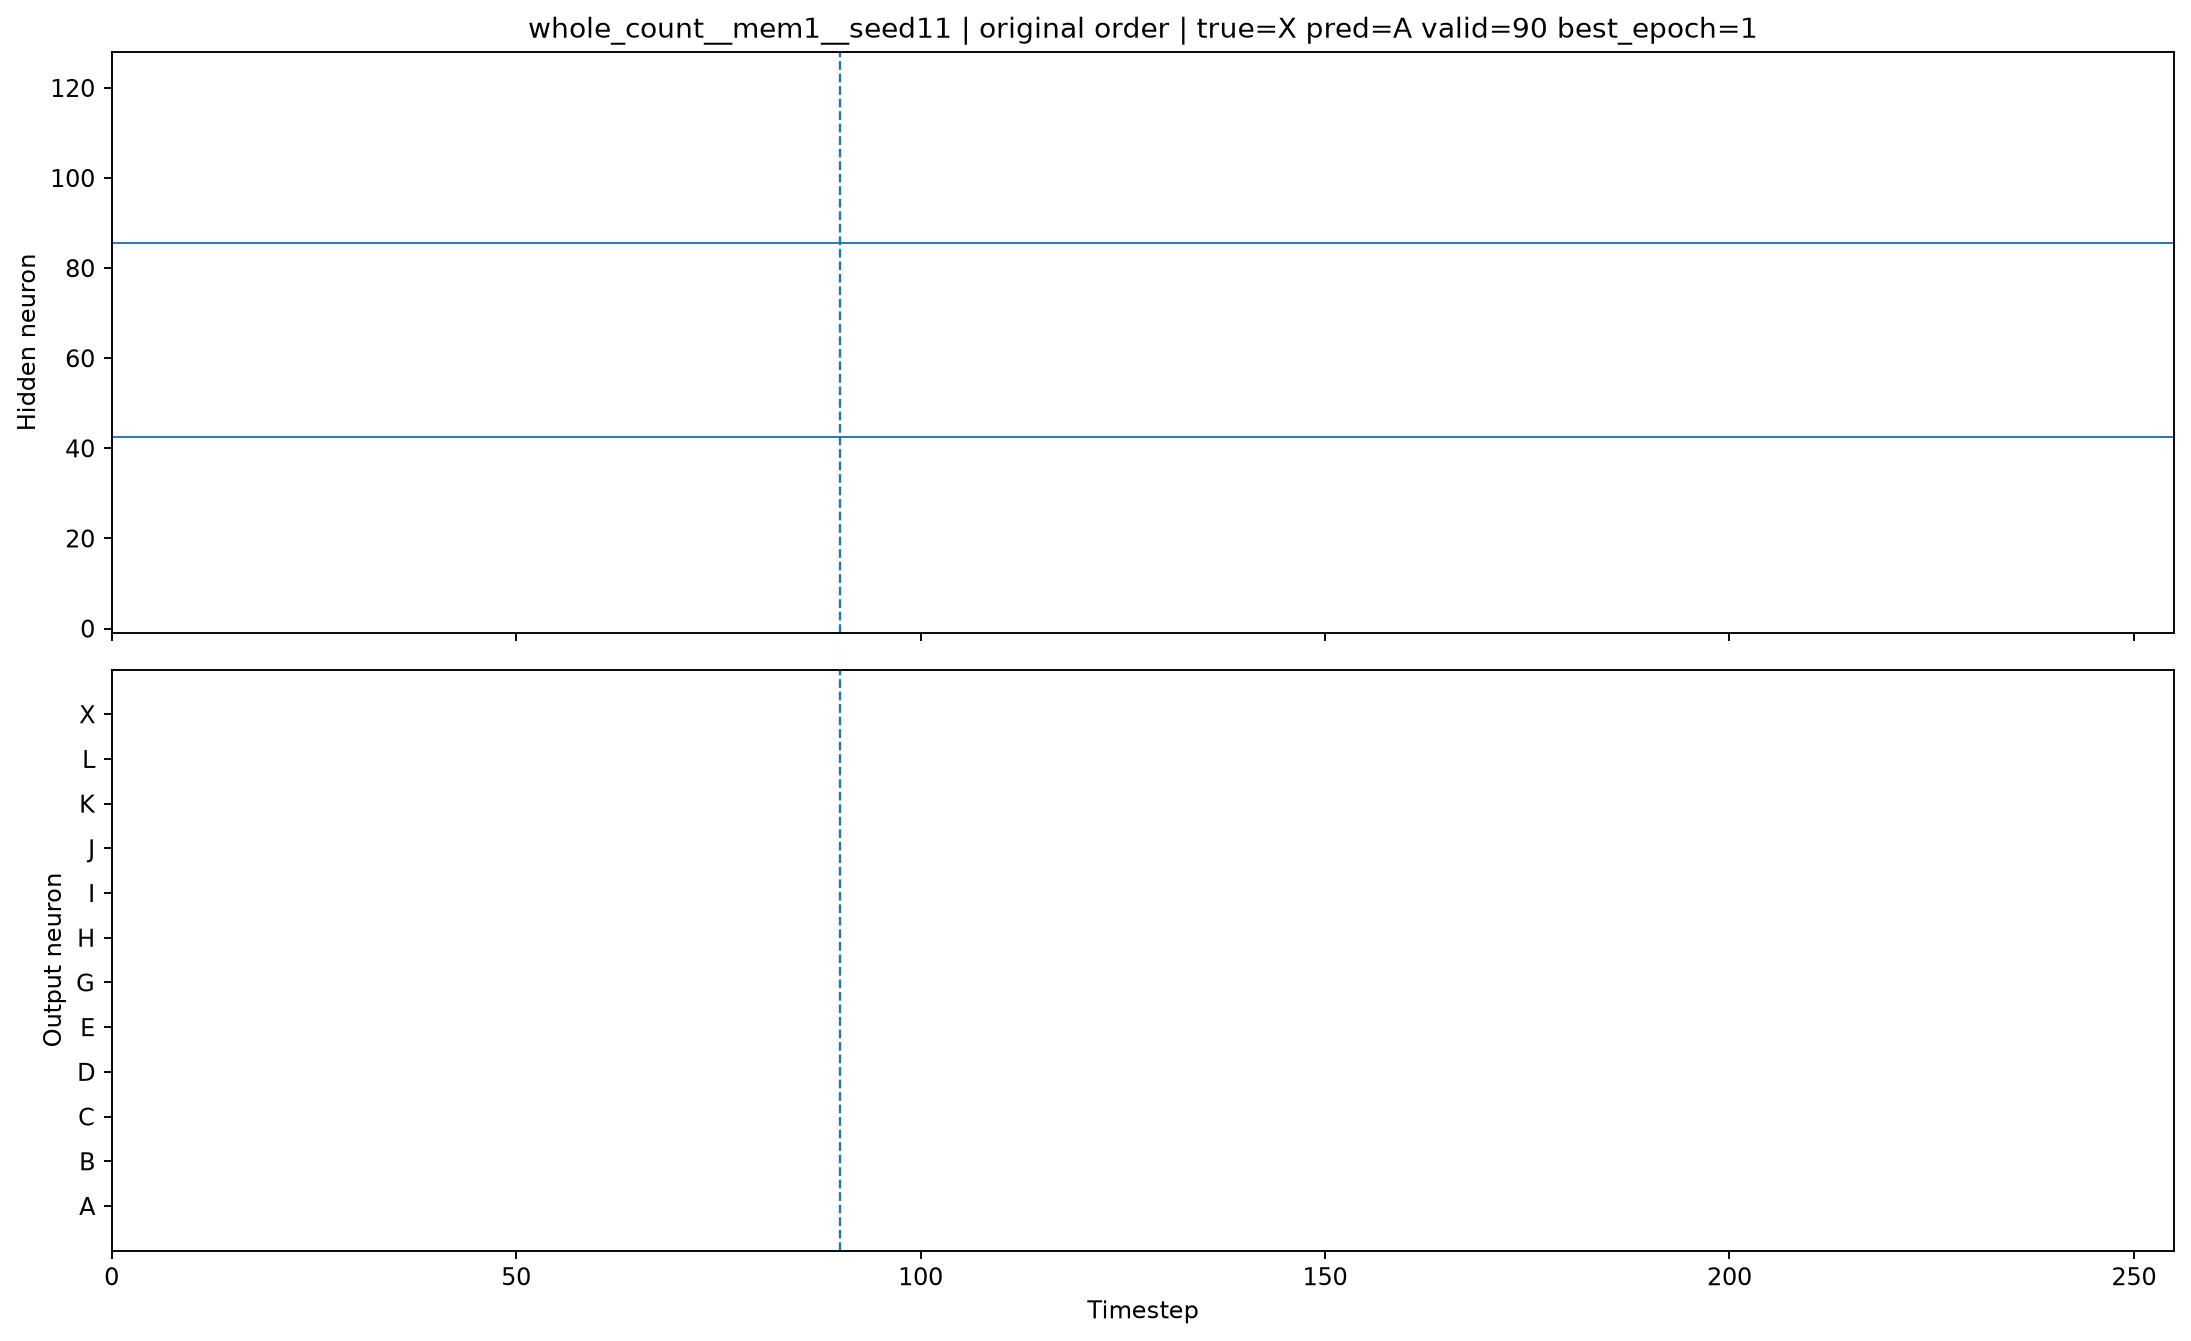

In [6]:
pair_rows = history_index[(history_index.objective == 'whole_count') & (history_index.mem_shift == 1) & (history_index.seed == 11)].sort_values('synapse_mode')
for _, row in pair_rows.iterrows():
    print(row.synapse_mode)
    display(Image(filename=str(REPO_ROOT / row.learning_curve_png)))
    display(Image(filename=str(REPO_ROOT / row.raster_png)))


## HCE original-order vs reversed-order rasters

legacy_unnormalized


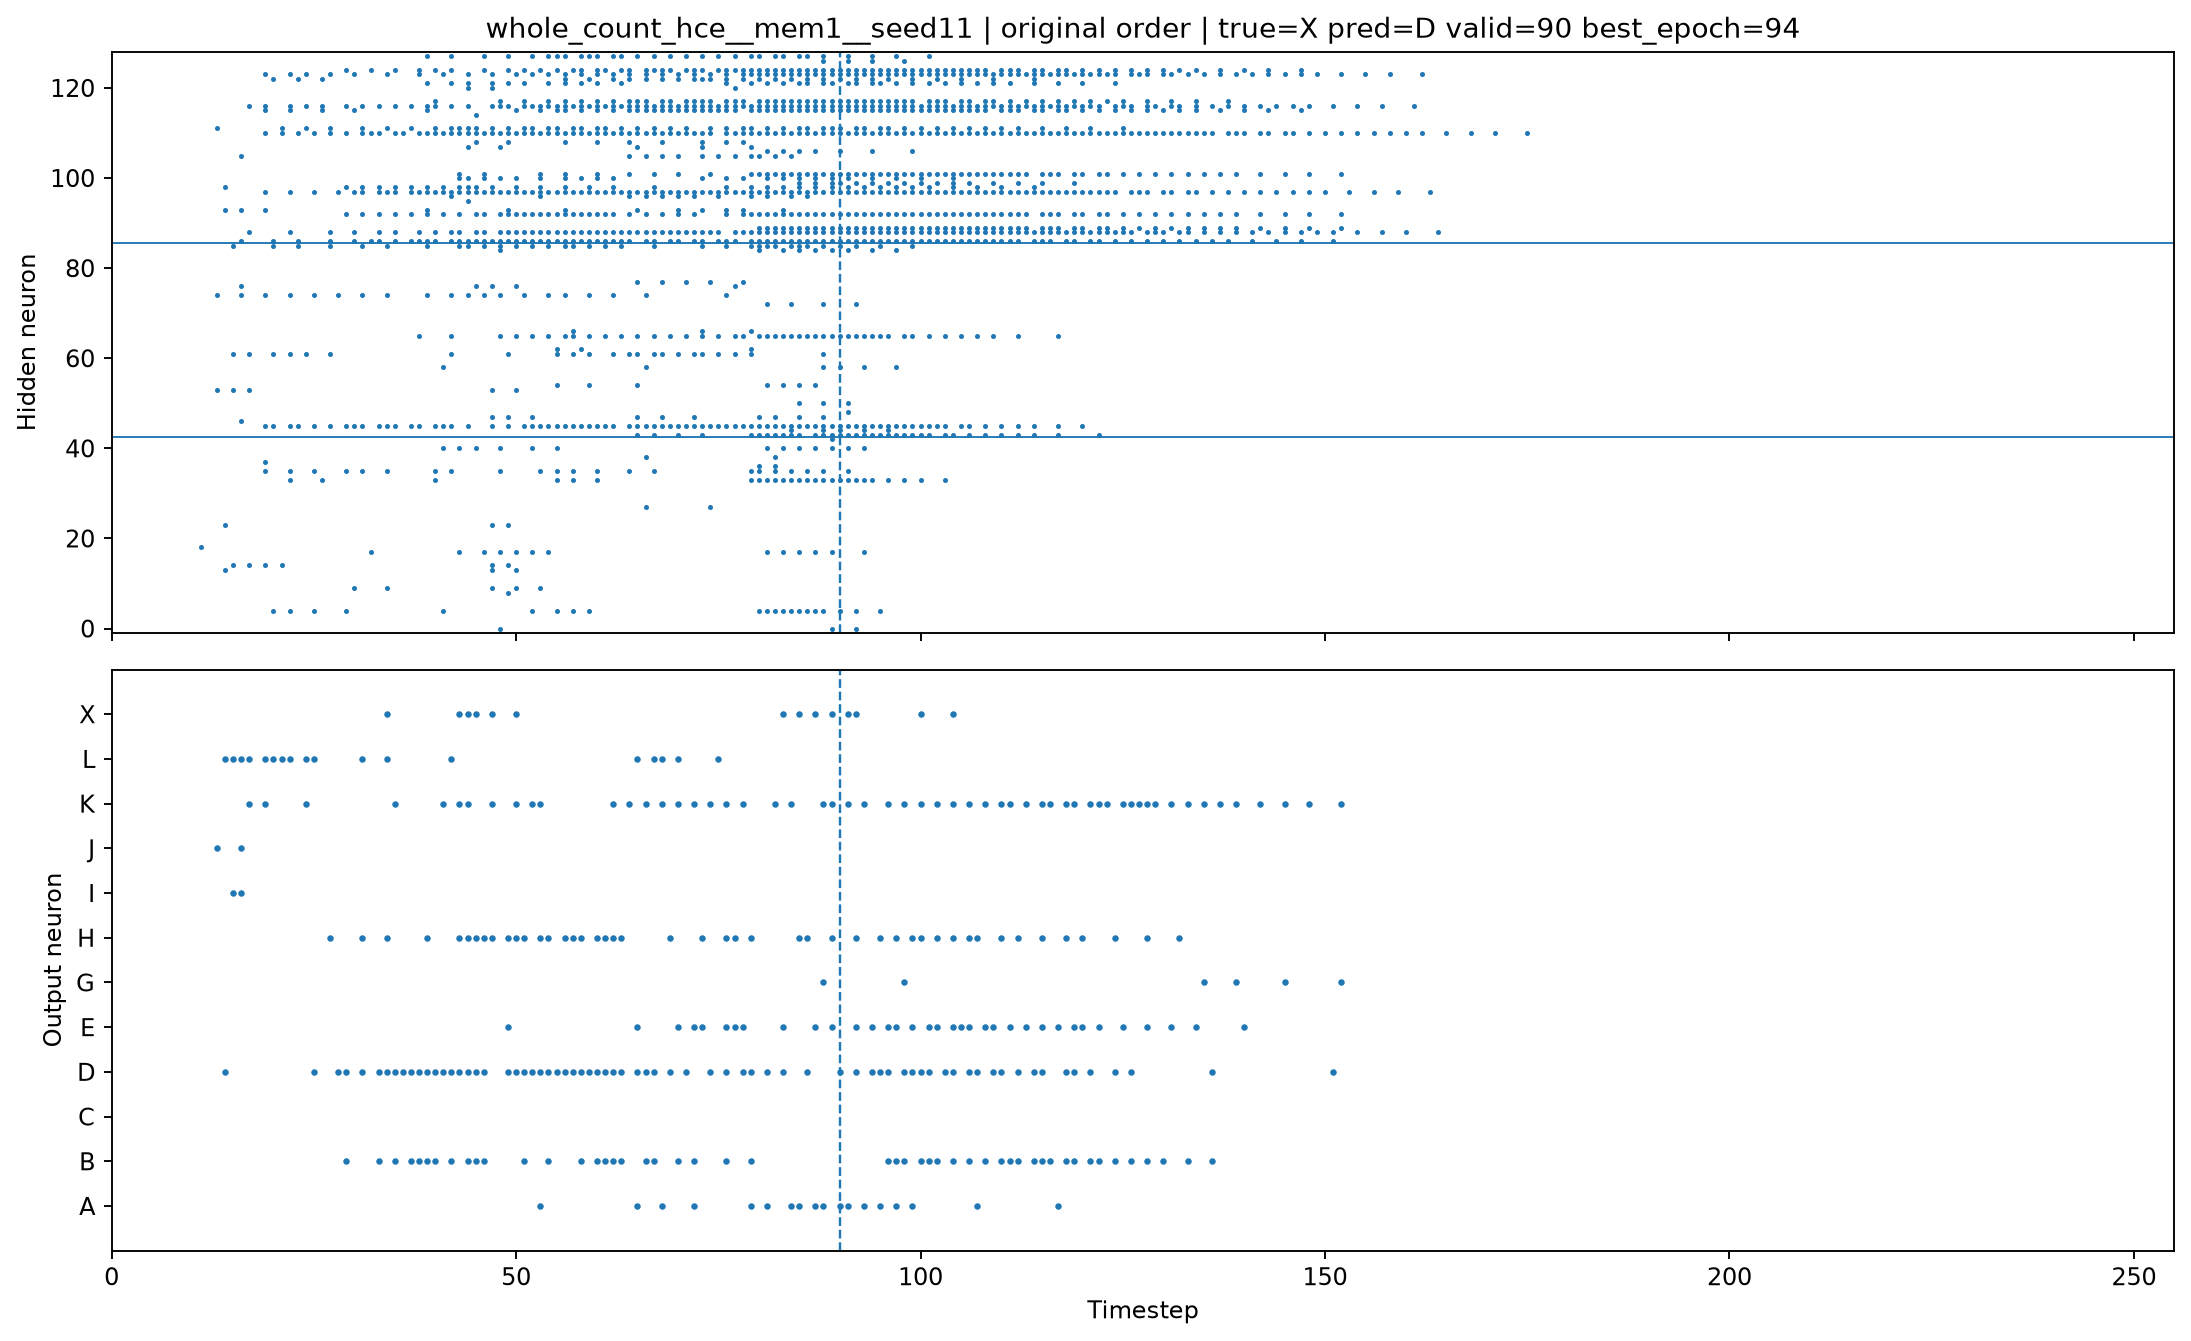

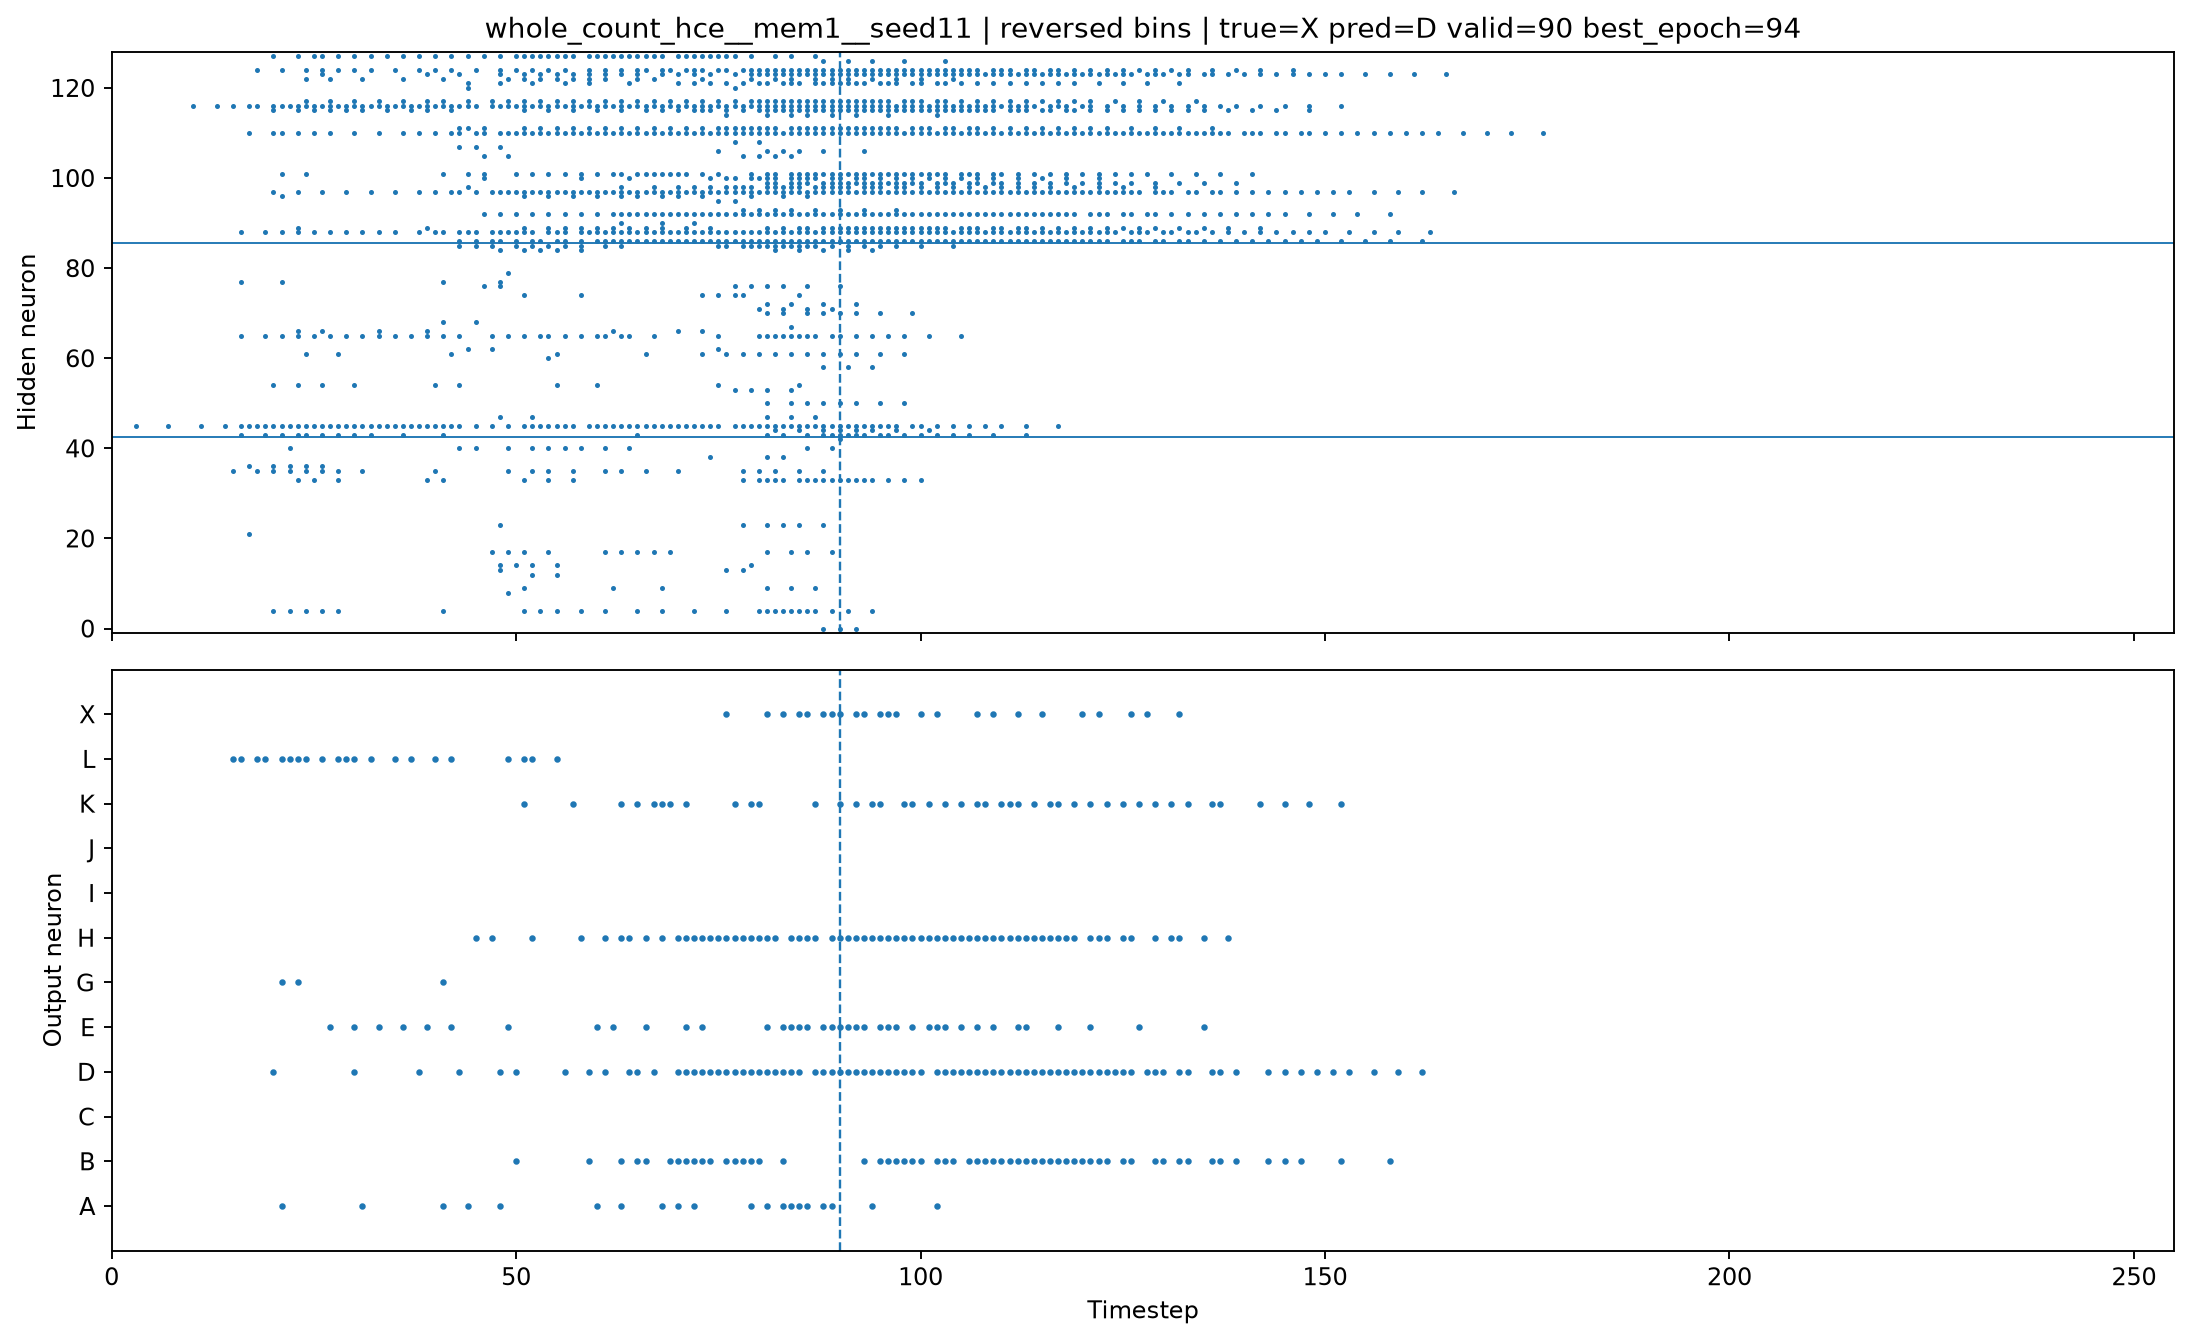

normalized_unit_dc


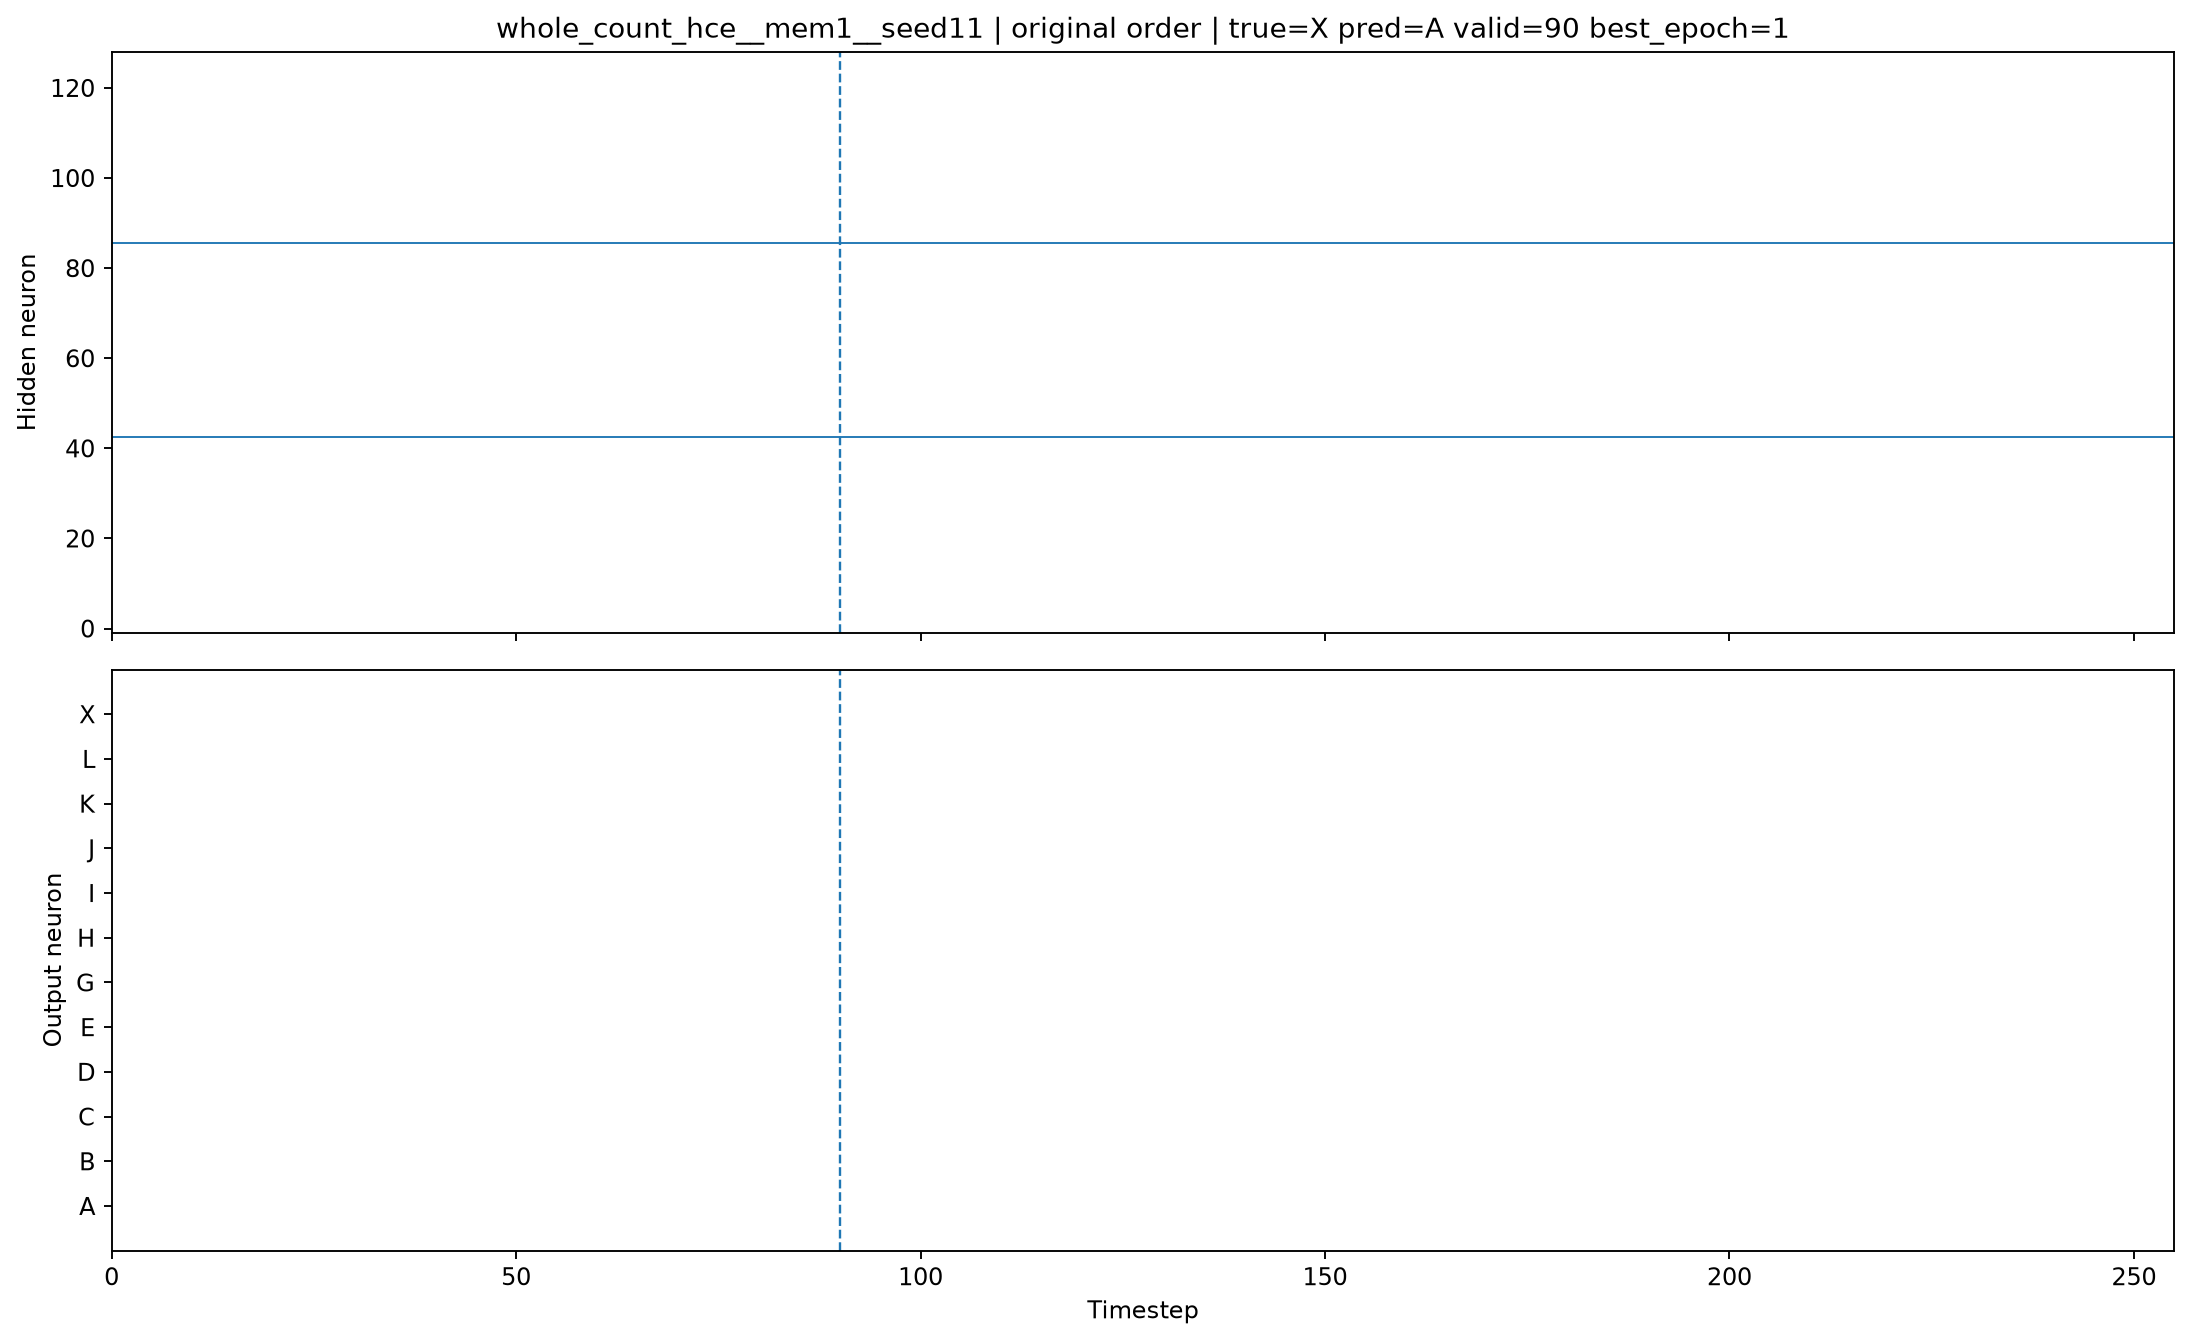

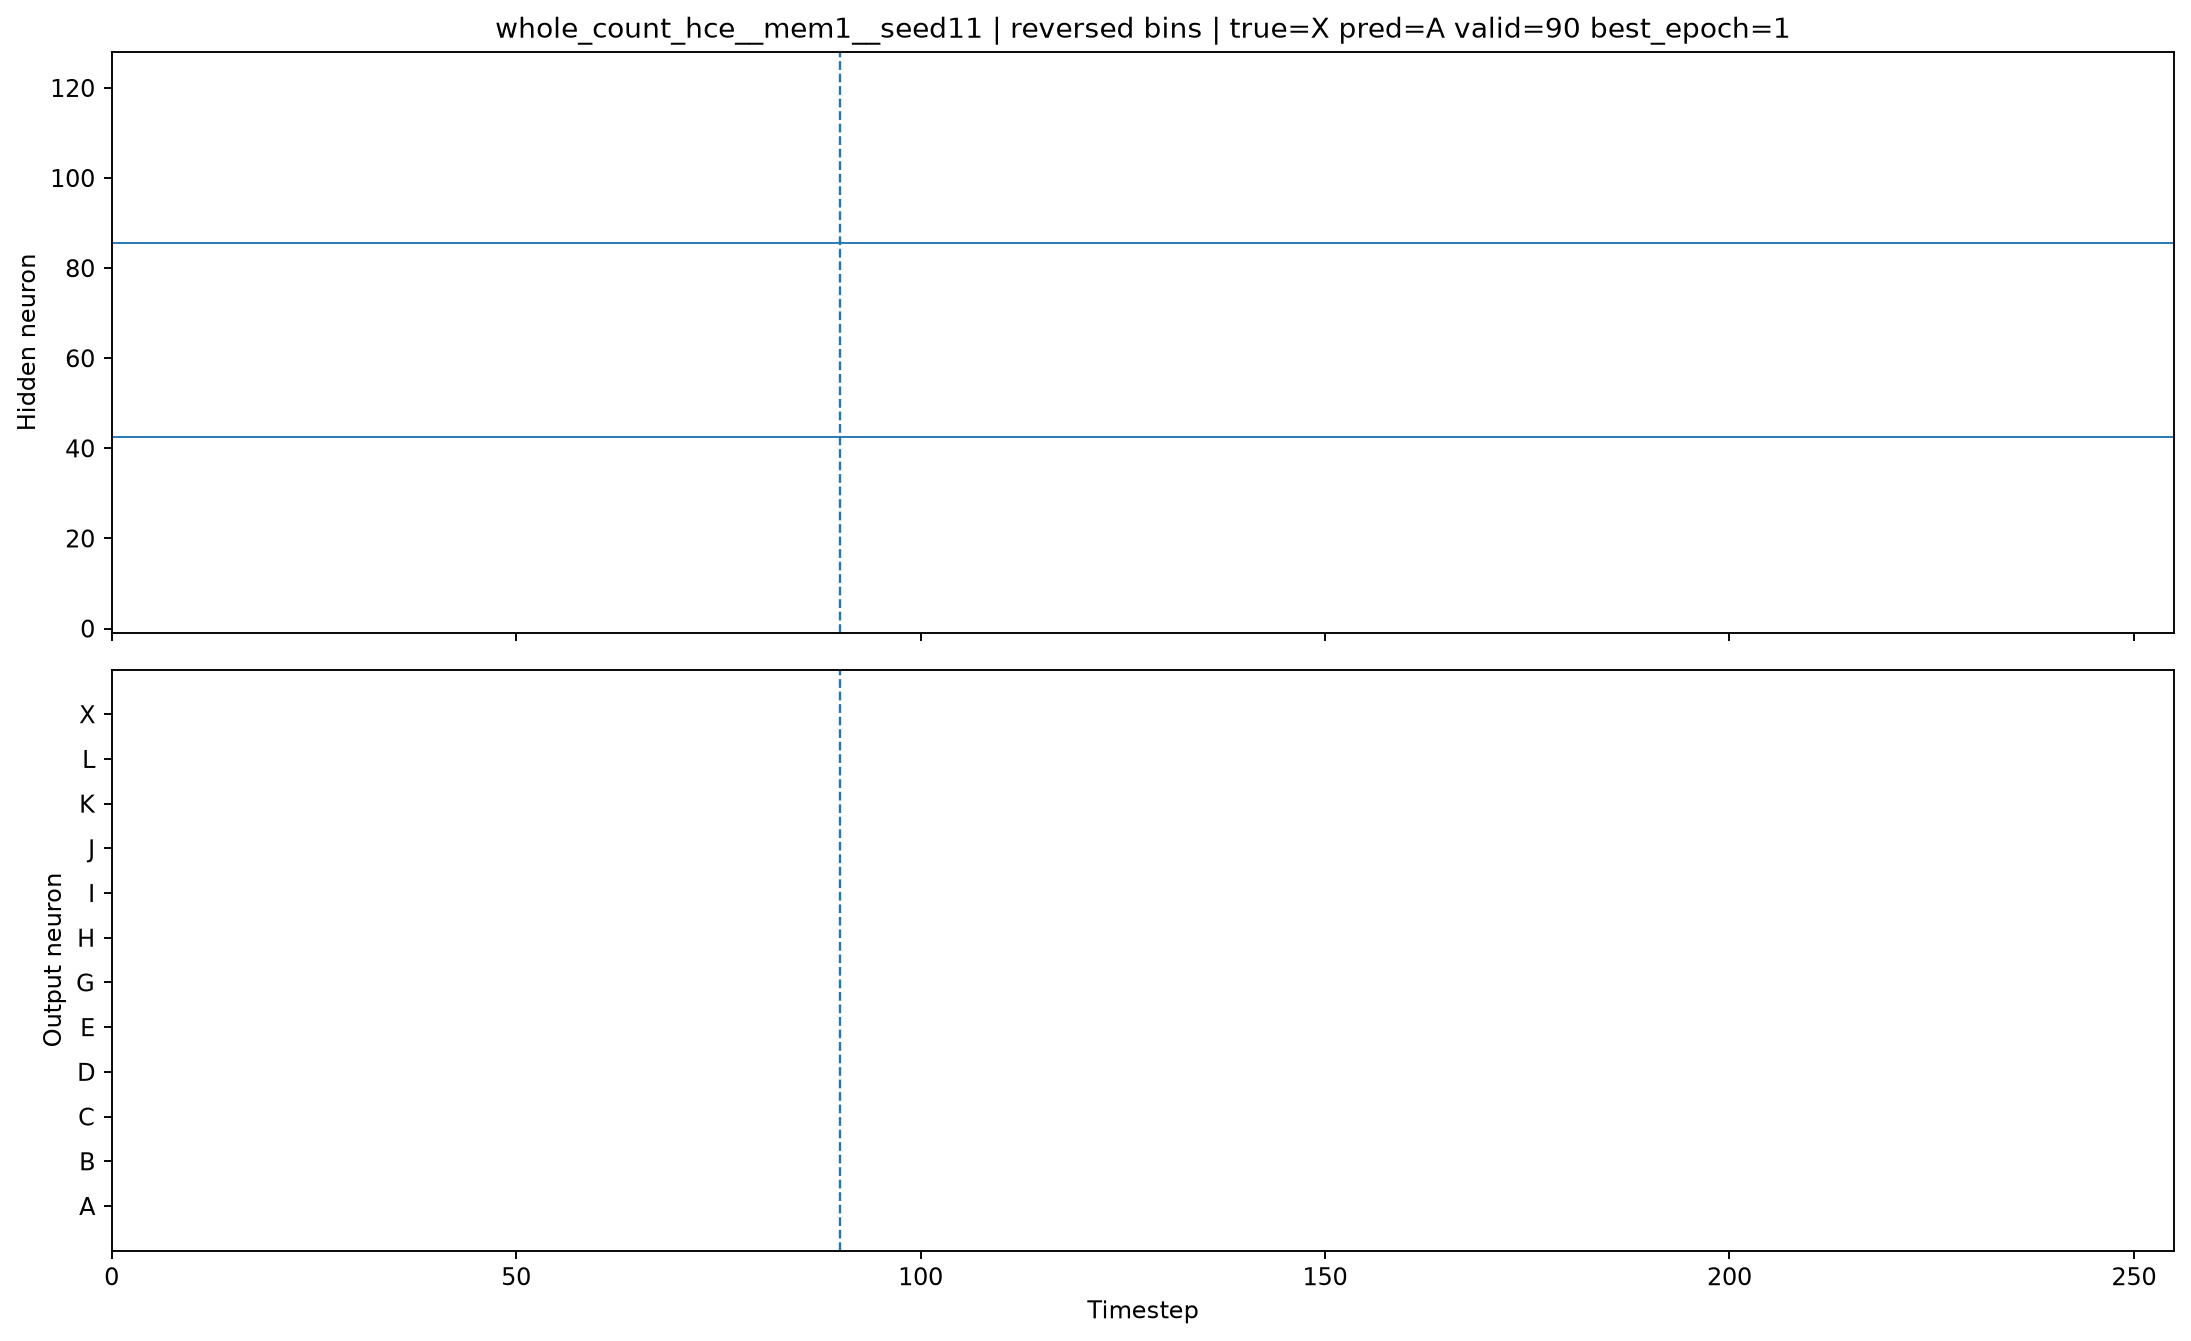

In [7]:
hce_rows = history_index[(history_index.objective == 'whole_count_hce') & (history_index.mem_shift == 1) & (history_index.seed == 11)].sort_values('synapse_mode')
for _, row in hce_rows.iterrows():
    original = REPO_ROOT / row.raster_png
    reversed_png = original.with_name(original.stem + '__reversed.png')
    print(row.synapse_mode)
    display(Image(filename=str(original)))
    display(Image(filename=str(reversed_png)))


## Interpretation checklist

1. At matched objective, membrane shift, and seed, how does removing `(1-alpha)` change BA?
2. Does the legacy update increase s5/s6 firing or post-end tail persistence as expected from its larger DC gain?
3. Is any legacy performance advantage accompanied by saturation/persistent activity rather than cleaner phase-aware evidence?
4. Does HCE or Contextual Gain interact differently with the two synaptic-current equations?
5. Which condition gets closest to Raw Fixed250 + Linear while preserving interpretable hidden activity?